# Healpix 降水绘图


In [1]:
import intake
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import healpy as hp
from pathlib import Path
from itertools import combinations

# -----------------------------
# Configuration
# -----------------------------
GRID_LABELS = ["R02B09"]
TIME_RES = "P1D"
ZOOM = 8
TROPICS_LAT = 30
BASELINE = "R02B09"

CATALOG_URL = "https://data.nextgems-h2020.eu/catalog.yaml"



In [2]:
# -----------------------------
# Load three grids and align time window
# -----------------------------
cat = intake.open_catalog(CATALOG_URL)
source = cat.ICON.C5.AMIP_CNTL

raw_ds = {
    g: source(grid=g, time=TIME_RES, zoom=ZOOM).to_dask()[["pr"]]
    for g in GRID_LABELS
}

for g in GRID_LABELS:
    ds = raw_ds[g]
    print(
        f"{g}: time={str(ds.time.values[0])[:10]} -> {str(ds.time.values[-1])[:10]}, "
        f"ntime={ds.sizes['time']}, npix={ds.sizes['cell']}"
    )

common_start = max(np.datetime64(raw_ds[g].time.values[0]) for g in GRID_LABELS)
common_end = min(np.datetime64(raw_ds[g].time.values[-1]) for g in GRID_LABELS)

if common_end < common_start:
    raise RuntimeError("No overlapping period among the three grids.")

aligned_ds = {
    g: raw_ds[g].sel(time=slice(common_start, common_end))
    for g in GRID_LABELS
}

print()
print("Common period:", str(common_start)[:10], "->", str(common_end)[:10])
for g in GRID_LABELS:
    print(f"{g}: aligned ntime={aligned_ds[g].sizes['time']}")


R02B09: time=1979-01-02 -> 1981-12-31, ntime=1095, npix=786432

Common period: 1979-01-02 -> 1981-12-31
R02B09: aligned ntime=1095


/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [5]:
# -----------------------------
# Healpix metadata, masks, and cache file paths
# -----------------------------
sample = aligned_ds[GRID_LABELS[0]]
npix = sample.sizes["cell"]
nside = int(sample.healpix.attrs.get("healpix_nside", hp.npix2nside(npix)))
healpix_order = str(sample.healpix.attrs.get("healpix_order", "nested")).lower()
is_nested = healpix_order.startswith("nest")

pixel_ids = np.arange(npix)
lon_deg, lat_deg = hp.pix2ang(nside, pixel_ids, nest=is_nested, lonlat=True)
tropics_mask = np.abs(lat_deg) <= TROPICS_LAT

print(f"nside={nside}, npix={npix}, order={healpix_order}, nested={is_nested}")
print(f"Tropical pixels (|lat| <= {TROPICS_LAT}): {tropics_mask.sum()} / {npix}")

period_tag = f"{str(common_start)[:10]}_{str(common_end)[:10]}"
mean_cache = None
var_cache = None

nside=256, npix=786432, order=nested, nested=True
Tropical pixels (|lat| <= 30): 393216 / 786432


In [ ]:
# -----------------------------
# Compute or load cached mean/variance maps
# pr units: kg m-2 s-1 -> mm/day by *86400
# -----------------------------
if mean_cache and var_cache:
    print("Loading cached maps...")
    mean_ds = xr.open_dataset(mean_cache)
    var_ds = xr.open_dataset(var_cache)
else:
    mean_maps = {}
    var_maps = {}

    for g in GRID_LABELS:
        print(f"Computing mean/variance maps for {g}...")
        pr_mmday = aligned_ds[g]["pr"] 
        mean_maps[g] = pr_mmday.mean("time").compute()
        var_maps[g] = pr_mmday.var("time").compute()

    mean_ds = xr.Dataset(mean_maps)
    var_ds = xr.Dataset(var_maps)

    mean_ds.attrs["description"] = "Precipitation climatological mean map"
    mean_ds.attrs["units"] = "mm/day"
    mean_ds.attrs["time_period"] = f"{str(common_start)[:10]} to {str(common_end)[:10]}"
    var_ds.attrs["description"] = "Precipitation temporal variance map"
    var_ds.attrs["units"] = "(mm/day)^2"
    var_ds.attrs["time_period"] = f"{str(common_start)[:10]} to {str(common_end)[:10]}"



Computing mean/variance maps for R02B09...


In [15]:

mean_maps = {g: mean_ds[g] for g in GRID_LABELS}
var_maps = {g: var_ds[g] for g in GRID_LABELS}

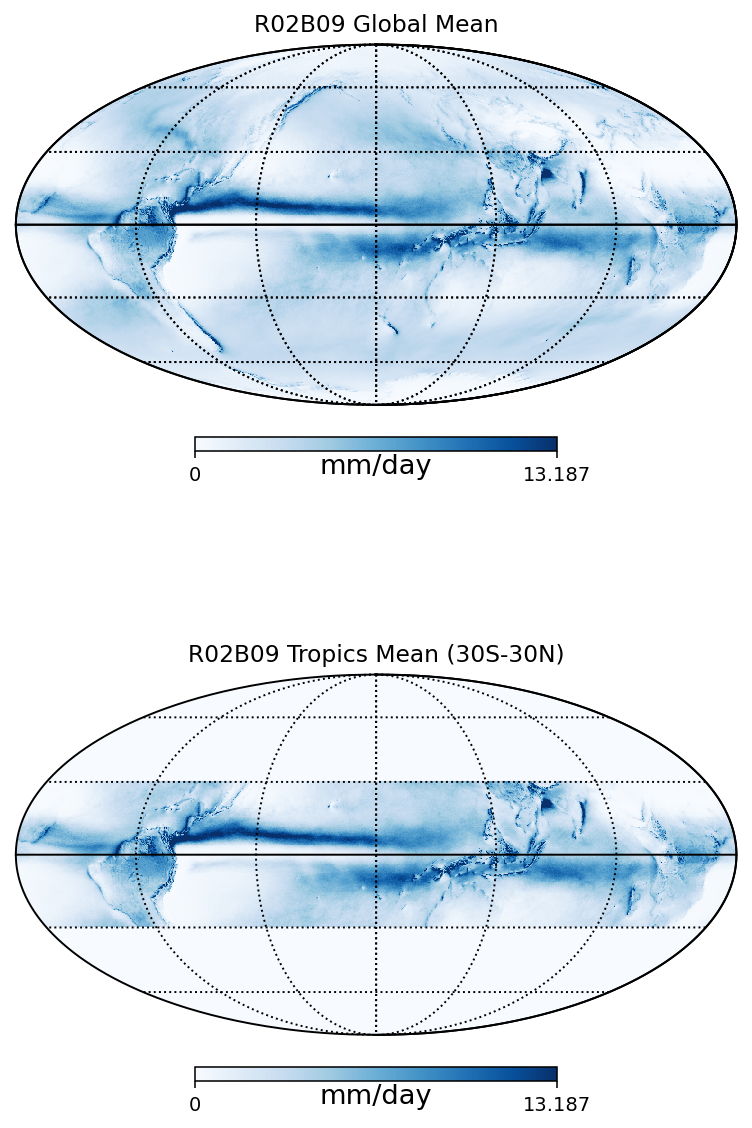

In [16]:
# -----------------------------
# Plot mean maps: global + tropics
# -----------------------------
def to_hp_array(da, mask=None):
    arr = np.asarray(da.values, dtype=np.float64)
    if mask is None:
        return arr
    out = arr.copy()
    out[~mask] = hp.UNSEEN
    return out

mean_vmax = float(
    np.nanquantile(
        np.concatenate([to_hp_array(mean_maps[g])*86400 for g in GRID_LABELS]),
        0.995,
    )
)

fig = plt.figure(figsize=(16, 9), dpi=140)

for i, g in enumerate(GRID_LABELS):
    hp.mollview(
        to_hp_array(mean_maps[g])*86400,
        nest=is_nested,
        fig=fig.number,
        sub=(2, 3, i + 1),
        min=0,
        max=mean_vmax,
        cmap="Blues",
        title=f"{g} Global Mean",
        unit="mm/day",
        cbar=True,
        notext=True,
        rot=(180, 0, 0)
    )
    hp.graticule(dpar=30, dmer=60, verbose=False)

for i, g in enumerate(GRID_LABELS):
    hp.mollview(
        to_hp_array(mean_maps[g], tropics_mask)*86400,
        nest=is_nested,
        fig=fig.number,
        sub=(2, 3, i + 4),
        min=0,
        max=mean_vmax,
        cmap="Blues",
        title=f"{g} Tropics Mean (30S-30N)",
        unit="mm/day",
        cbar=True,
        notext=True,
        rot=(180, 0, 0)
    )
    hp.graticule(dpar=30, dmer=60, verbose=False)

plt.show()



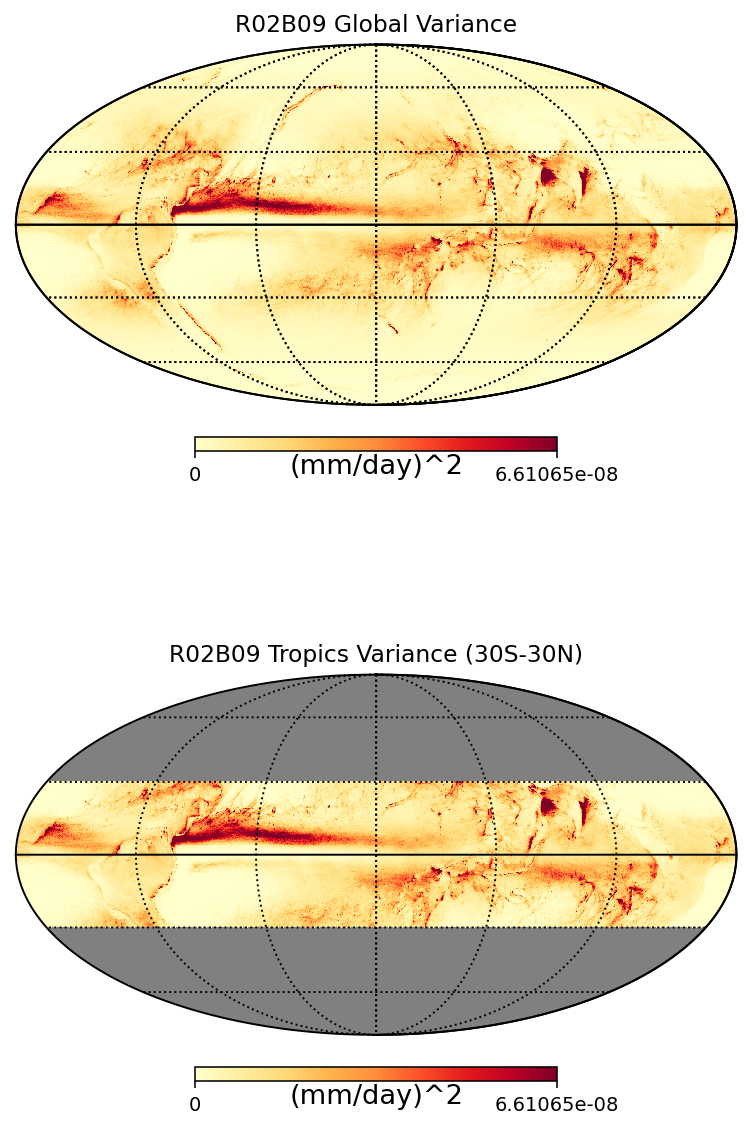

In [13]:
# -----------------------------
# Plot variance maps: global + tropics
# -----------------------------
var_vmax = float(
    np.nanquantile(
        np.concatenate([to_hp_array(var_maps[g]) for g in GRID_LABELS]),
        0.995,
    )
)

fig = plt.figure(figsize=(16, 9), dpi=140)

for i, g in enumerate(GRID_LABELS):
    hp.mollview(
        to_hp_array(var_maps[g]),
        nest=is_nested,
        fig=fig.number,
        sub=(2, 3, i + 1),
        min=0,
        max=var_vmax,
        cmap="YlOrRd",
        title=f"{g} Global Variance",
        unit="(mm/day)^2",
        cbar=True,
        notext=True,
        rot=(180, 0, 0)
    )
    hp.graticule(dpar=30, dmer=60, verbose=False)

for i, g in enumerate(GRID_LABELS):
    hp.mollview(
        to_hp_array(var_maps[g], tropics_mask),
        nest=is_nested,
        fig=fig.number,
        sub=(2, 3, i + 4),
        min=0,
        max=var_vmax,
        cmap="YlOrRd",
        title=f"{g} Tropics Variance (30S-30N)",
        unit="(mm/day)^2",
        cbar=True,
        notext=True,
        rot=(180, 0, 0)
    )
    hp.graticule(dpar=30, dmer=60, verbose=False)

plt.show()
